In [11]:
library(ggplot2)
library(ggridges)
source("~/helpers.R")
library(reshape2)

In [22]:
data1=read.table("cosine_sim.tsv",header=TRUE,sep='\t')
data1$same_fold=FALSE
data1$same_fold[data1$fold1==data1$fold2]=TRUE
print(nrow(data1))
data1=data1[data1$same_fold==FALSE,]
print(nrow(data1))
data1$same_fold=NULL
names(data1)=c("BPNetProfile","BPNetCounts","BinaryClass","BinaryReg","GKMExplain","fold1","fold2")
data1=melt(data1,id=c("fold1","fold2"))
head(data1)

[1] 250000
[1] 200000


,fold1,fold2,variable,value
,<int>,<int>,<fct>,<dbl>
1,0,1,BPNetProfile,0.9510081
2,0,1,BPNetProfile,0.9668789
3,0,1,BPNetProfile,0.9376850
4,0,1,BPNetProfile,0.9980834
5,0,1,BPNetProfile,0.6384772
6,0,1,BPNetProfile,0.9019180


In [23]:
options(repr.plot.width=20, repr.plot.height=20)

p1=ggplot(data1,
       aes(y=variable,
           x=value))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 3, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  xlim(0.5,1.2)+
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  coord_cartesian(clip = "off") +
  ggtitle("Cosine Similarity, K562 DNASE") +
  theme_bw(20)


In [24]:
data2=read.table("spearman.tsv",header=TRUE,sep='\t')
data2$same_fold=FALSE
data2$same_fold[data2$fold1==data2$fold2]=TRUE
print(nrow(data2))
data2=data2[data2$same_fold==FALSE,]
print(nrow(data2))
data2$same_fold=NULL
names(data2)=c("BPNetProfile","BPNetCounts","BinaryClass","BinaryReg","GKMExplain","fold1","fold2")
data2=melt(data2,id=c("fold1","fold2"))
head(data2)


p2=ggplot(data2,
       aes(y=variable,
           x=value))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 3, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  xlim(0,1.2)+
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  coord_cartesian(clip = "off") +
  ggtitle("Spearman, K562 DNASE") +
  theme_bw(20)


[1] 250000
[1] 200000


,fold1,fold2,variable,value
,<int>,<int>,<fct>,<dbl>
1,0,1,BPNetProfile,0.8586113
2,0,1,BPNetProfile,0.8857284
3,0,1,BPNetProfile,0.7710549
4,0,1,BPNetProfile,0.8898615
5,0,1,BPNetProfile,0.5003764
6,0,1,BPNetProfile,0.7675981


In [25]:
data3=read.table("pearson.tsv",header=TRUE,sep='\t')
data3$same_fold=FALSE
data3$same_fold[data3$fold1==data3$fold2]=TRUE
print(nrow(data3))
data3=data3[data3$same_fold==FALSE,]
print(nrow(data3))
data3$same_fold=NULL
names(data3)=c("BPNetProfile","BPNetCounts","BinaryClass","BinaryReg","GKMExplain","fold1","fold2")
data3=melt(data3,id=c("fold1","fold2"))
head(data3)
p3=ggplot(data3,
       aes(y=variable,
           x=value))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 3, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  xlim(0.5,1.2)+
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  coord_cartesian(clip = "off") +
  ggtitle("Pearson, K562 DNASE") +
  theme_bw(20)

[1] 250000
[1] 200000


,fold1,fold2,variable,value
,<int>,<int>,<fct>,<dbl>
1,0,1,BPNetProfile,0.9499144
2,0,1,BPNetProfile,0.9663505
3,0,1,BPNetProfile,0.9374135
4,0,1,BPNetProfile,0.9980755
5,0,1,BPNetProfile,0.6553261
6,0,1,BPNetProfile,0.8935431


Picking joint bandwidth of 0.00708

Warning message:
“Removed 34882 rows containing non-finite values (stat_density_ridges).”
Picking joint bandwidth of 0.00852

Warning message:
“Removed 264 rows containing non-finite values (stat_density_ridges).”
Picking joint bandwidth of 0.00727

Warning message:
“Removed 35952 rows containing non-finite values (stat_density_ridges).”


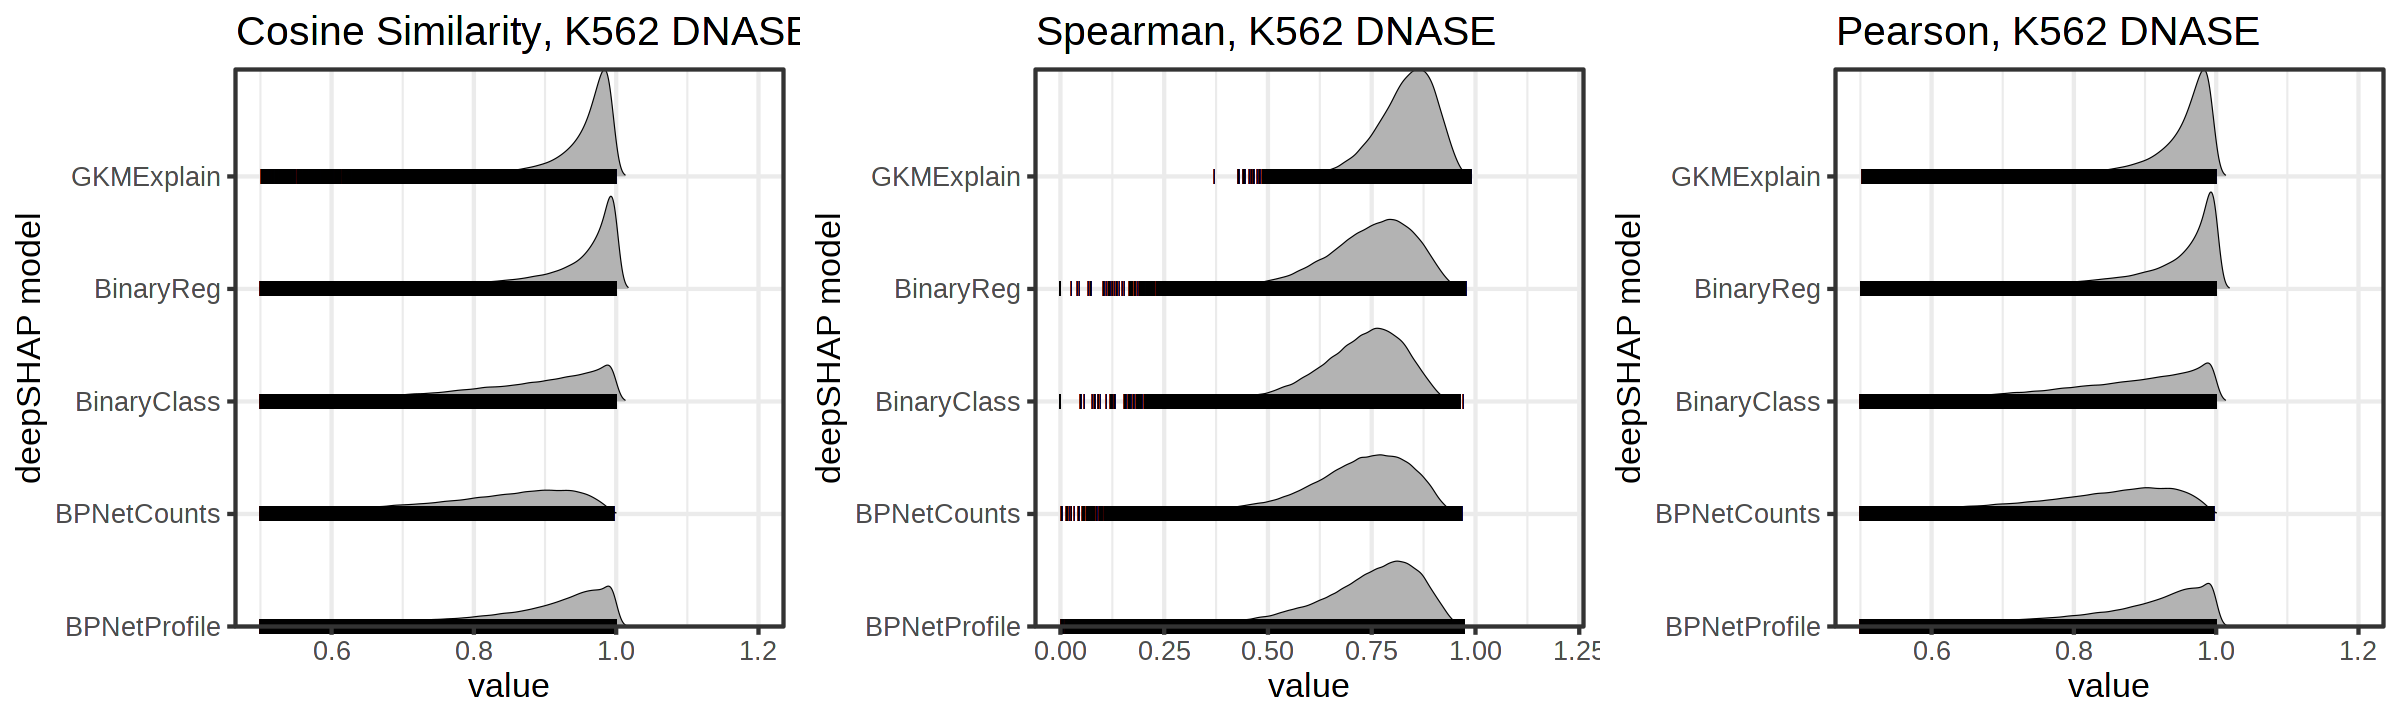

In [26]:
options(repr.plot.width=20, repr.plot.height=6)
multiplot(p1,p2,p3,cols=3)